In [2]:
include("plot_fig2.jl")
include("plot_fig3.jl")
include("plot_fig4.jl")
include("plot_fig5.jl")

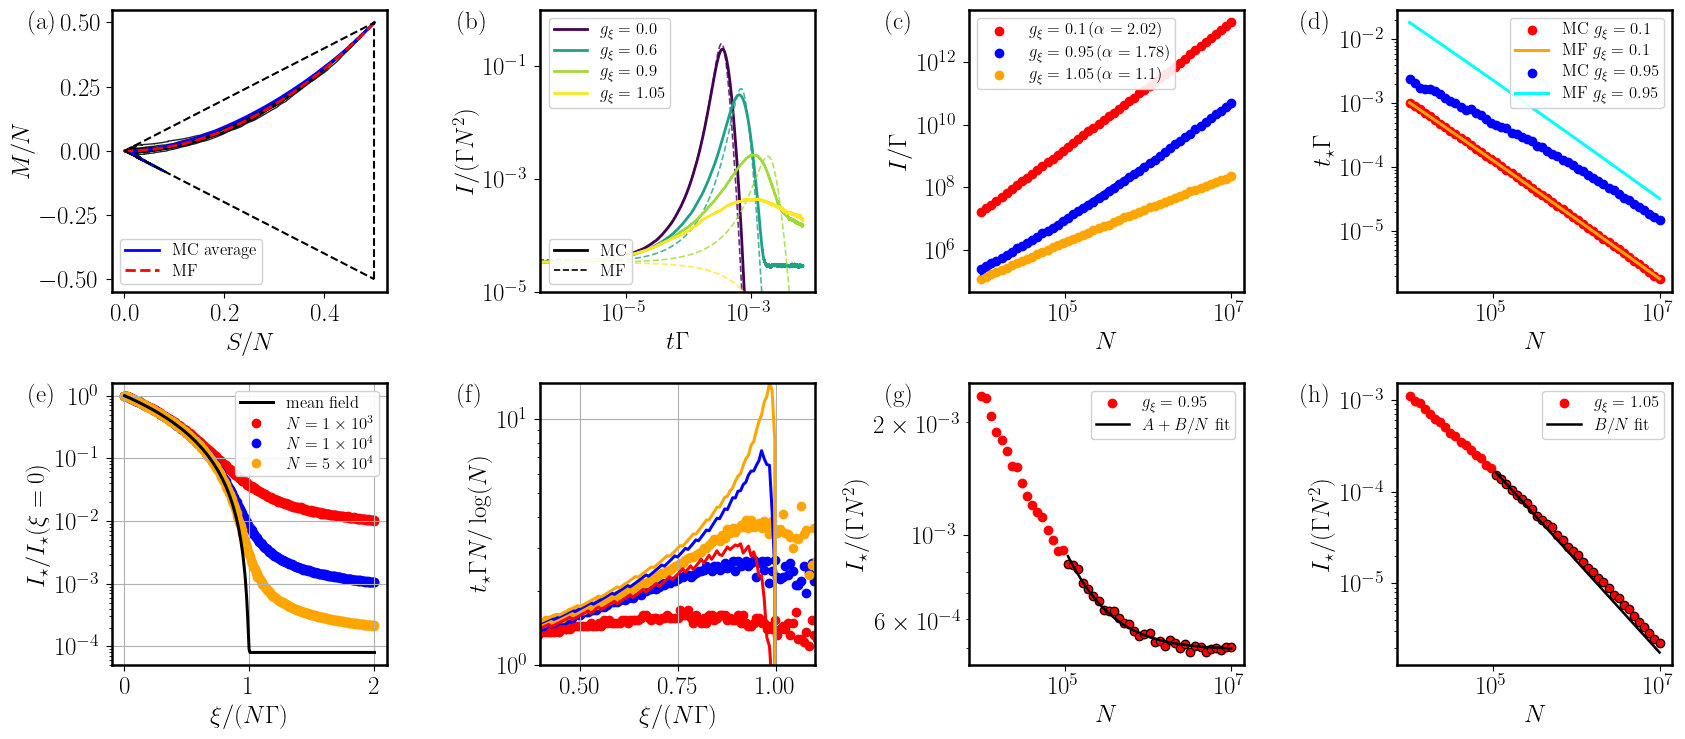

In [20]:
fig2a_file = "../plot_data/fig2a_data.jld2"
compare_file = "../plot_data/fig_compare_mc_mf_intensity.jld2"
scan_file = "../plot_data/dephasing_main_scan.jld2"
outfile = "../data/fig2.pdf"

W, H = latex_plot_setup(ratio=0.9, scale=1.8)

fig, axes = subplots(
    ncols = 4,
    nrows = 2,
    figsize = (4.0 * W, 2.0 * H)
)

plot_fig2a!(axes[1,1], load(fig2a_file)["data"])
plot_dephasing_panel_a!(axes[2,1], load(scan_file))
plot_compare_mc_mf_intensity!(axes[1,2], load(compare_file))
plot_dephasing_panel_b!(axes[2,2], load(scan_file))


datafile = joinpath(@__DIR__, "..", "plot_data", "dephasing_finiteN_scan.jld2")
d = load(datafile)


plot_dephasing_panel_d!(axes[1,3], d)
plot_dephasing_peak_time_panel!(axes[1,4], d)
plot_dephasing_panel_c_below_fit!(axes[2,3], d; which = 2)
plot_dephasing_panel_c_above_fit!(axes[2,4], d; which = 1)

tight_layout()

axes[1,1].text(-0.3, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.3, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[1,3].text(-0.3, 1.0, "(c)", transform=axes[1,3].transAxes, va="top")
axes[2,4].text(-0.35, 1.0, "(d)", transform=axes[1,4].transAxes, va="top")
axes[2,1].text(-0.3, 1.0, "(e)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.3, 1.0, "(f)", transform=axes[2,2].transAxes, va="top")
axes[2,3].text(-0.3, 1.0, "(g)", transform=axes[2,3].transAxes, va="top")
axes[2,4].text(-0.35, 1.0, "(h)", transform=axes[2,4].transAxes, va="top")

savefig("../data/huge_dephasing.pdf", bbox_inches = "tight")

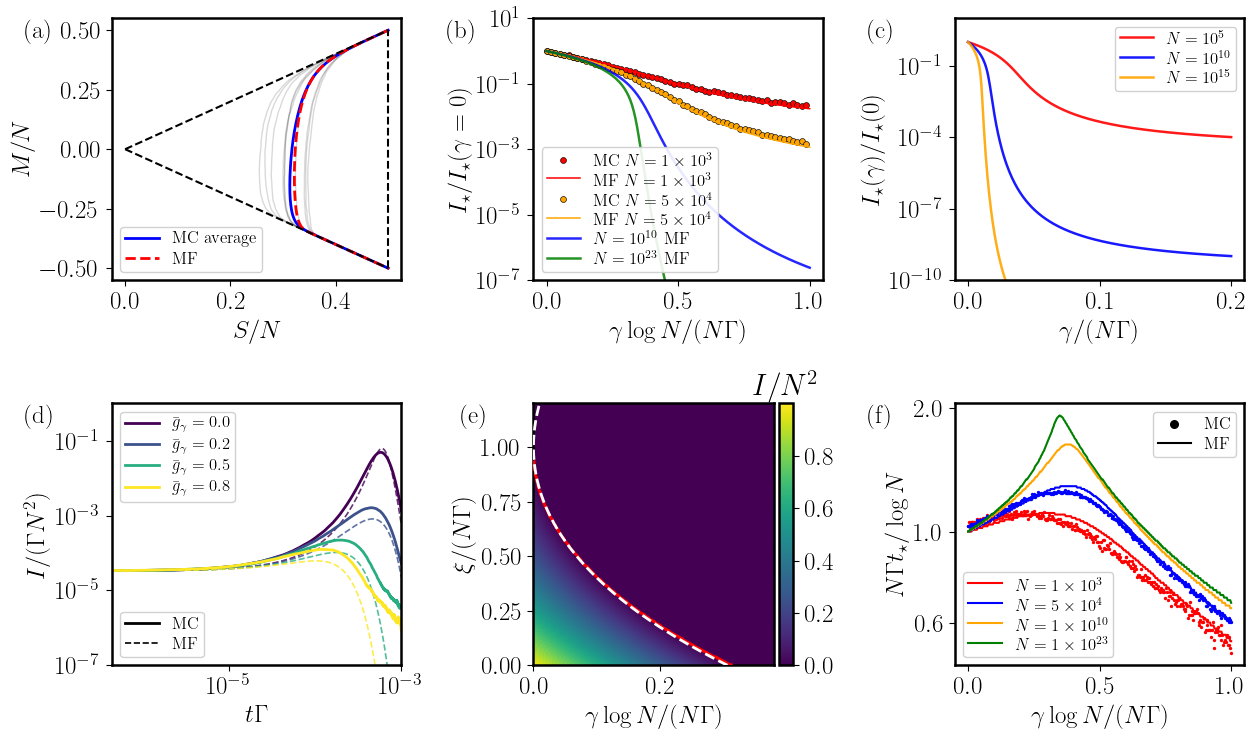

In [30]:
traj_file = "../plot_data/fig_trajectories_gamma.jld2"
intensity_file = "../plot_data/fig_compare_mc_mf_intensity_gamma.jld2"
outfile = "../data/fig4.pdf"

data_traj = namedtuple_to_dict(load(traj_file)["data"])
data_int = load(intensity_file)

w, h = latex_plot_setup(ratio=0.9, scale=1.8)
fig, axes = subplots(ncols=3, nrows=2, figsize=(3w, 2h))

plot_fig2b_gamma!(axes[1,1], data_traj)
plot_compare_mc_mf_intensity_gamma!(axes[2,1], data_int)

axes[2,1].set_ylim(bottom=1e-7)
axes[2,1].set_xlim(right=1e-3)

tight_layout()

sharp_file = "../plot_data/spont_sharpening_data.jld2"
collapse_file = "../plot_data/spont_collapse_data.jld2"
ggamma_file = "../plot_data/spont_meanfield_g_gamma_data.jld2"
phase_file = "../plot_data/spont_phase_diagram_100.jld2"
times_file = "../plot_data/times_spont_meanfield.jld2"
outfile = "../data/fig5.pdf"


data_sharp = load(sharp_file)
data_coll = load(collapse_file)
plot_spont_scaling_single!(axes[1,2], data_sharp, data_coll)

data = load(ggamma_file)
plot_spont_meanfield_g_gamma!(axes[1,3], data)
axes[1,3].set_ylim(bottom = 1e-10, top = 10)

d = load(phase_file)
plot_spont_phase_diagram!(
    axes[2,2], d;
    show_contour = true,
    show_analytic_boundary = true,
    contour_tol = 1e-3,
    rescale_intensity = 4.0
)

data_mc = load(collapse_file)
data_mf = load(times_file)
plot_spont_peak_times!(axes[2,3], data_mc, data_mf)

tight_layout()

axes[1,1].text(-0.3, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.3, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[1,3].text(-0.3, 1.0, "(c)", transform=axes[1,3].transAxes, va="top")
axes[2,1].text(-0.3, 1.0, "(d)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.3, 1.0, "(e)", transform=axes[2,2].transAxes, va="top")
axes[2,3].text(-0.3, 1.0, "(f)", transform=axes[2,3].transAxes, va="top")
savefig("../data/huge_spontaneous.pdf", bbox_inches = "tight")